In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from Utilities.CoordinateManager import CoordinateManager

# Scaling factor of 4x
lr_shape = (8, 8)     # Low resolution
hr_shape = (32, 32)   # High resolution

# Generate coordinates
lr_coords = CoordinateManager.CreateCoordinates(lr_shape)
hr_coords = CoordinateManager.CreateCoordinates(hr_shape)

# Convert to numpy
lr_coords = lr_coords.numpy()
hr_coords = hr_coords.numpy()

#### Side by side generated coordinates

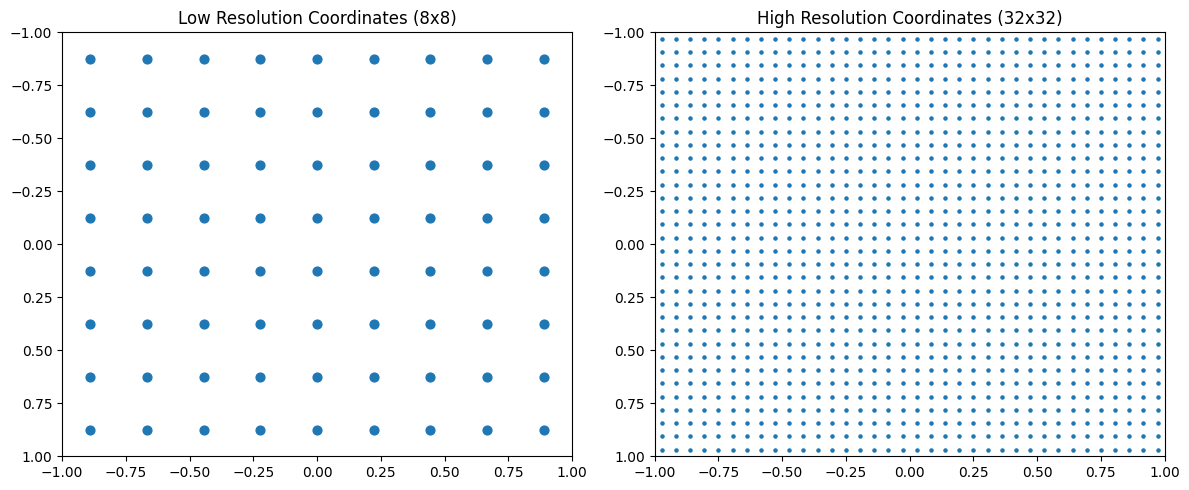

In [14]:
plt.figure(figsize=(12, 5))

# Common ticks
ticks = np.linspace(-1, 1, 9) 

# --- LR plot ---
plt.subplot(1, 2, 1)
plt.scatter(lr_coords[:, 1], lr_coords[:, 0], s=40)
plt.title("Low Resolution Coordinates (8x8)")
plt.xlim(-1, 1)
plt.ylim(1, -1) 
plt.xticks(ticks)
plt.yticks(ticks)

# --- HR plot ---
plt.subplot(1, 2, 2)
plt.scatter(hr_coords[:, 1], hr_coords[:, 0], s=5)
plt.title("High Resolution Coordinates (32x32)")
plt.xlim(-1, 1)
plt.ylim(1, -1)  
plt.xticks(ticks)
plt.yticks(ticks)

plt.tight_layout()
plt.show()

##### Overlayed the 2 coordinate systems

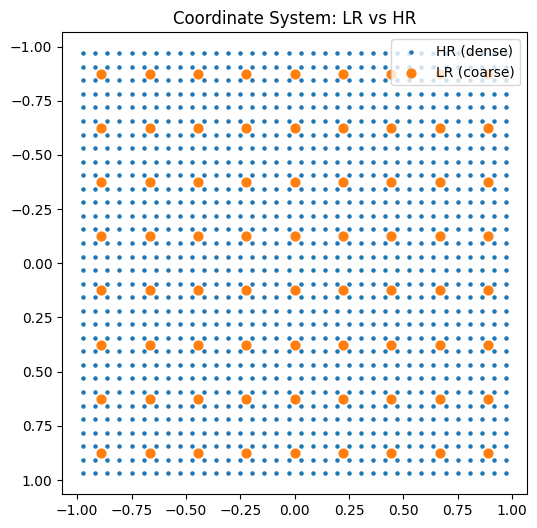

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(hr_coords[:, 1], hr_coords[:, 0], s=5, label="HR (dense)")
plt.scatter(lr_coords[:, 1], lr_coords[:, 0], s=40, label="LR (coarse)")

plt.title("Coordinate System: LR vs HR")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### Coordiante axis and grid as RGB pixels

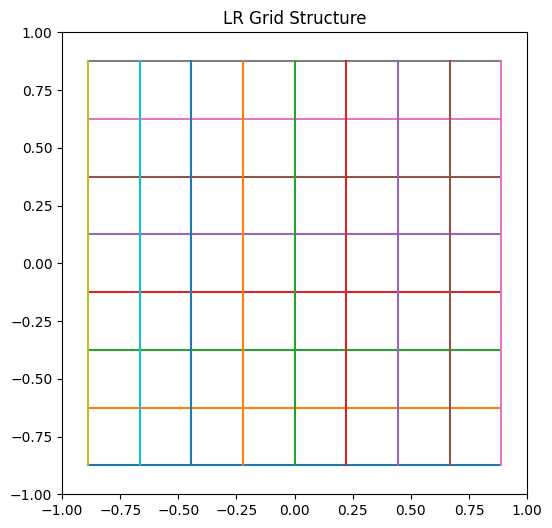

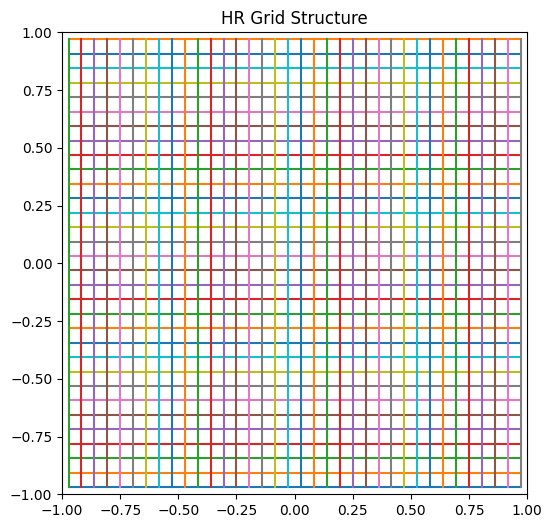

In [15]:
def plot_grid(coords, shape, title):
    coords = coords.reshape(shape[0], shape[1], 2)

    ticks = np.linspace(-1, 1, 9)

    plt.figure(figsize=(6, 6))

    # Draw horizontal lines
    for i in range(shape[0]):
        plt.plot(coords[i, :, 1], coords[i, :, 0], '-')

    # Draw vertical lines
    for j in range(shape[1]):
        plt.plot(coords[:, j, 1], coords[:, j, 0], '-')

    plt.xlim(-1, 1)
    plt.ylim(1, -1) 
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()


plot_grid(CoordinateManager.CreateCoordinates(lr_shape, flatten=False).numpy(),
          lr_shape,
          "LR Grid Structure")

plot_grid(CoordinateManager.CreateCoordinates(hr_shape, flatten=False).numpy(),
          hr_shape,
          "HR Grid Structure")



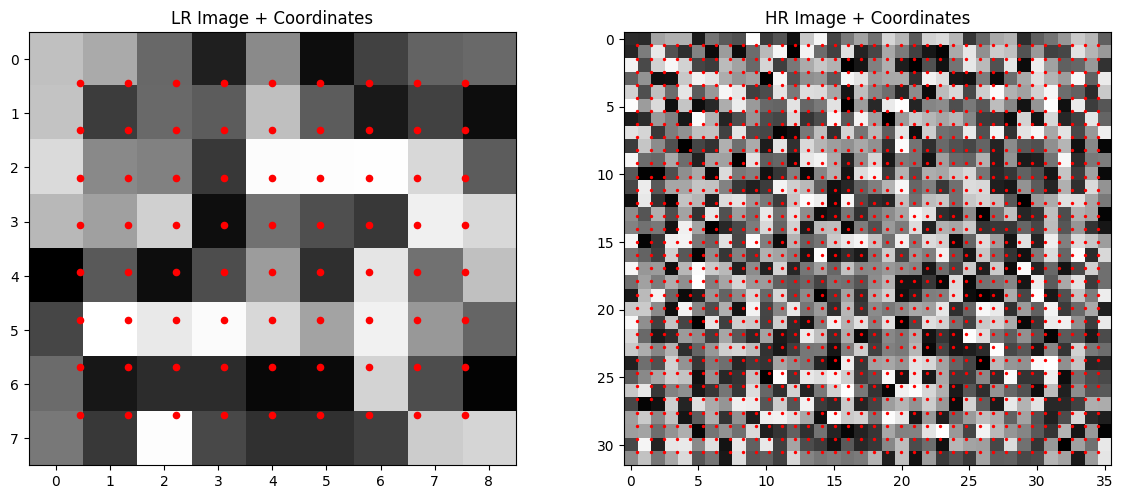

In [17]:
lr_img = np.random.rand(*lr_shape)
hr_img = np.random.rand(*hr_shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lr_img, cmap='gray')
plt.scatter(
    (lr_coords[:, 1] + 1) / 2 * (lr_shape[1] - 1),
    (lr_coords[:, 0] + 1) / 2 * (lr_shape[0] - 1),
    s=20, c='red'
)
plt.title("LR Image + Coordinates")

plt.subplot(1, 2, 2)
plt.imshow(hr_img, cmap='gray')
plt.scatter(
    (hr_coords[:, 1] + 1) / 2 * (hr_shape[1] - 1),
    (hr_coords[:, 0] + 1) / 2 * (hr_shape[0] - 1),
    s=2, c='red'
)
plt.title("HR Image + Coordinates")

plt.tight_layout()
plt.show()